# Modeling and Evaluation

In this notebook, we build and evaluate a regression model to predict student exam scores. Since `Exam_Score` is a continuous numerical variable, this is a regression problem rather than a classification problem.

The workflow includes:

1. Loading the cleaned student performance dataset
2. Separating features and target variable
3. Splitting the data into training and testing sets
4. Training baseline models
5. Using Optuna to tune an XGBoost Regressor
6. Building a stacking ensemble model
7. Evaluating model performance using regression metrics
8. Visualizing prediction quality, residuals, feature importance, and correlations

In [7]:
import pandas as pd

df = pd.read_csv("CleanedStudentPerformance.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Study_Efficiency
0,23,84,1,3,0,7,73,1,1,0,...,2.0,0,1,3,0,1.0,1.0,1,67,2.875000
1,19,64,1,2,0,8,59,1,1,2,...,2.0,0,-1,4,0,2.0,2.0,0,61,2.111111
2,24,98,2,2,1,7,91,2,1,2,...,2.0,0,0,4,0,3.0,1.0,1,74,3.000000
3,29,89,1,2,1,8,98,2,1,1,...,2.0,0,-1,4,0,1.0,2.0,1,71,3.222222
4,19,92,2,2,1,6,65,2,1,3,...,3.0,0,0,4,0,2.0,1.0,0,70,2.714286


## Feature and Target Selection

The target variable is `Exam_Score`, which represents the numerical score we want to predict.

All other columns are used as input features. The model will learn relationships between student behavior, academic support, demographic factors, and final exam performance.

In [12]:
X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

## Train-Test Split

The dataset is split into training and testing sets. The training set is used to fit the model, while the testing set is held out to evaluate how well the model generalizes to unseen data.

An 80/20 split is used, with 80% of the data for training and 20% for testing.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Baseline Models

Three regression models are initialized:

- **Linear Regression:** Captures simple linear relationships.
- **Random Forest Regressor:** Captures nonlinear patterns using multiple decision trees.
- **XGBoost Regressor:** A gradient boosting model that often performs well on tabular datasets.

The Random Forest model is manually strengthened using selected hyperparameters.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

xgb = XGBRegressor(random_state=42)

## Hyperparameter Tuning with Optuna

Optuna is used to tune the XGBoost Regressor. Hyperparameter tuning helps identify stronger parameter values for the model instead of relying on default settings.

The objective is to minimize RMSE, meaning the model searches for parameters that reduce prediction error.

In [23]:
import optuna
import numpy as np

from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }

    model = XGBRegressor(**params, random_state=42)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    rmse = -np.mean(scores)

    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

[I 2026-05-07 16:58:45,321] A new study created in memory with name: no-name-65dc3563-fdd6-469a-9559-6cf100ed50e4
[I 2026-05-07 16:58:47,850] Trial 0 finished with value: 2.2313919624028618 and parameters: {'n_estimators': 456, 'max_depth': 5, 'learning_rate': 0.059584097440658824, 'subsample': 0.6389199146851119, 'colsample_bytree': 0.6519715951233923}. Best is trial 0 with value: 2.2313919624028618.
[I 2026-05-07 16:58:52,124] Trial 1 finished with value: 2.3315303439482515 and parameters: {'n_estimators': 368, 'max_depth': 6, 'learning_rate': 0.21649124660696378, 'subsample': 0.8217455384482342, 'colsample_bytree': 0.6165691436393734}. Best is trial 0 with value: 2.2313919624028618.
[I 2026-05-07 16:58:57,733] Trial 2 finished with value: 2.5148508936910865 and parameters: {'n_estimators': 131, 'max_depth': 7, 'learning_rate': 0.292104348657338, 'subsample': 0.6410823706173949, 'colsample_bytree': 0.91521409488678}. Best is trial 0 with value: 2.2313919624028618.
[I 2026-05-07 16:58

## Best XGBoost Model

After Optuna identifies the best hyperparameters, the tuned XGBoost model is trained on the full training set. This tuned model is later used inside the stacking ensemble.

In [26]:
best_params = study.best_params

xgb_best = XGBRegressor(**best_params, random_state=42)
xgb_best.fit(X_train, y_train)

best_params

{'n_estimators': 339,
 'max_depth': 3,
 'learning_rate': 0.054704517001830294,
 'subsample': 0.866737685483743,
 'colsample_bytree': 0.9693382811114589}

## Stacking Ensemble Model

A stacking ensemble combines multiple models to improve prediction performance.

This ensemble uses:

- Linear Regression
- Random Forest Regressor
- Tuned XGBoost Regressor

The final estimator is also the tuned XGBoost model. This allows the ensemble to combine the strengths of the base models while using a strong final model to make the final prediction.

In [29]:
from sklearn.ensemble import StackingRegressor

stack_model = StackingRegressor(
    estimators=[
        ("lr", lr),
        ("rf", rf),
        ("xgb", xgb_best)
    ],
    final_estimator=xgb_best
)

stack_model.fit(X_train, y_train)

StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('rf',
                               RandomForestRegressor(max_depth=10,
                                                     min_samples_split=5,
                                                     n_estimators=300,
                                                     random_state=42)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.9693382811114589,
                                            device=None,
                                            early_stopping_rounds=None,
                                            enable_categor...
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.054704517001830294,
                                               max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=3,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=339, n_jobs=None,
                                               num_parallel_tree=None, ...))

## Model Evaluation Metrics

The final stacking ensemble is evaluated using several regression metrics:

- **MAE:** Average absolute prediction error
- **MSE:** Average squared prediction error
- **RMSE:** Penalizes larger errors more strongly
- **MAPE:** Average percentage prediction error
- **R² Score:** Proportion of exam score variance explained by the model

In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

preds = stack_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)
mape = mean_absolute_percentage_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R2:", r2)

MAE: 0.49751315210662705
MSE: 3.3617724572828487
RMSE: 1.833513691599506
MAPE: 0.00696466888734513
R2: 0.7621680498123169


## Metric Interpretation

The final stacking ensemble model demonstrated strong predictive performance on the student exam score dataset. The ensemble combined Linear Regression, Random Forest Regression, and an Optuna-tuned XGBoost Regressor to improve overall prediction accuracy and model generalization.

### Final Metrics

- **MAE (Mean Absolute Error):** ~0.50  
  - On average, the model’s predictions differed from actual exam scores by less than one point.

- **MSE (Mean Squared Error):** ~3.36  
  - The model maintained relatively low squared prediction error across the dataset.

- **RMSE (Root Mean Squared Error):** ~1.83  
  - Larger prediction mistakes remained limited overall, indicating stable model performance.

- **MAPE (Mean Absolute Percentage Error):** ~0.007  
  - The model achieved very low percentage-based prediction error.

- **R² Score:** ~0.76  
  - The model explained approximately 76% of the variance in student exam scores.

### Overall Interpretation

The stacking ensemble generalized well across the majority of students and produced highly accurate predictions. While the model slightly underpredicted a few extremely high-performing students, this behavior is expected in educational datasets where exceptional scores are less common. Overall, the ensemble model successfully captured meaningful relationships between student behaviors, academic factors, and exam outcomes.

## Actual vs Predicted Exam Scores

This visualization compares predicted exam scores against actual exam scores. A stronger model will have points clustered close to the diagonal reference line.

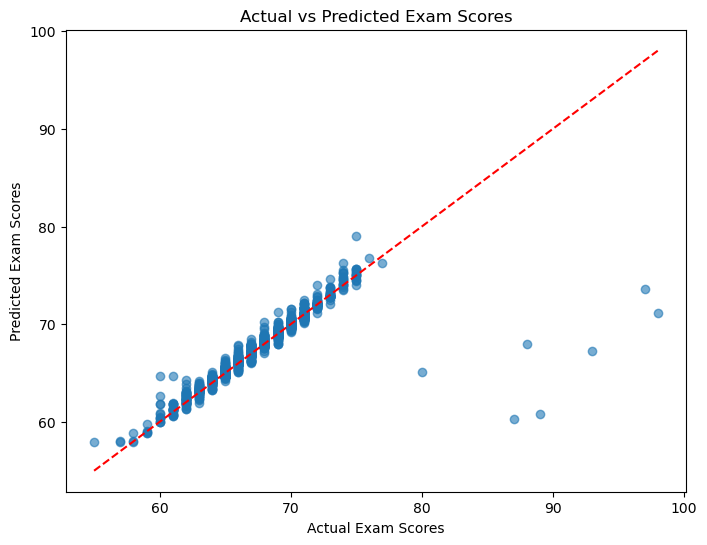

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, preds, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Exam Scores")
plt.ylabel("Predicted Exam Scores")
plt.title("Actual vs Predicted Exam Scores")

plt.show()

## Actual vs Predicted Exam Scores Interpretation

This visualization compares the model’s predicted exam scores against the actual exam scores from the testing dataset.

### Observations

- The red dashed diagonal line represents perfect predictions where predicted scores exactly match actual scores.
- Most data points cluster closely around the diagonal line, indicating strong predictive accuracy.
- The model performs especially well within the common score range between approximately 60–75.
- A small number of very high-performing students were underpredicted by the model.

### Insights

- The ensemble model demonstrates strong overall predictive capability across the majority of students.
- Predictions remain stable with relatively low random scatter around the ideal prediction line.
- The close alignment between actual and predicted scores supports the strong R² value achieved by the model.
- Underprediction of rare high-score outliers highlights a realistic limitation of the model rather than overfitting.

### What This Means for the Model

The model successfully learned meaningful academic and behavioral patterns associated with exam performance. Although rare extreme outcomes remain harder to predict, the ensemble model generalized effectively and maintained strong prediction accuracy across most students in the dataset.

## Residual Plot

The residual plot shows prediction errors by comparing residuals against predicted values. Residuals close to zero indicate accurate predictions.

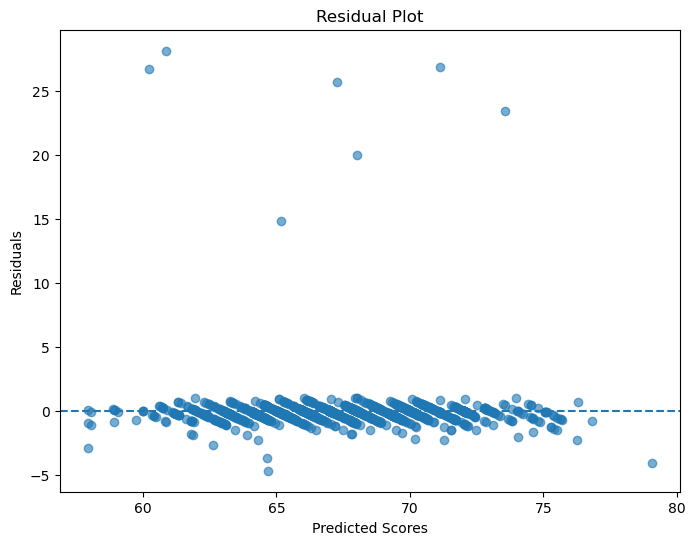

In [38]:
residuals = y_test - preds

plt.figure(figsize=(8, 6))

plt.scatter(preds, residuals, alpha=0.6)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Residual Plot Interpretation

The residual plot visualizes prediction errors by plotting residual values against predicted exam scores.

### Observations

- Residuals close to zero indicate highly accurate predictions.
- Most residual values remain tightly clustered around the zero line.
- Residuals appear randomly distributed, suggesting the model does not show strong systematic bias.
- A few larger positive residuals correspond to students whose actual scores were significantly higher than predicted.

### Insights

- The residual distribution suggests stable model performance with relatively low prediction variance.
- Random residual dispersion indicates that the model generalized effectively rather than memorizing training data.
- Most prediction errors remain small, demonstrating strong reliability and consistency.
- Large positive residual outliers suggest that exceptional student performance remains more difficult for the model to predict accurately.

### What This Means for the Model

The residual plot confirms that the ensemble model maintains stable and reliable prediction behavior across most score ranges. The absence of strong residual patterns supports the conclusion that the model generalized appropriately and did not heavily overfit the training data.

## Feature Importance

Feature importance helps explain which variables contributed most strongly to the XGBoost model’s predictions.

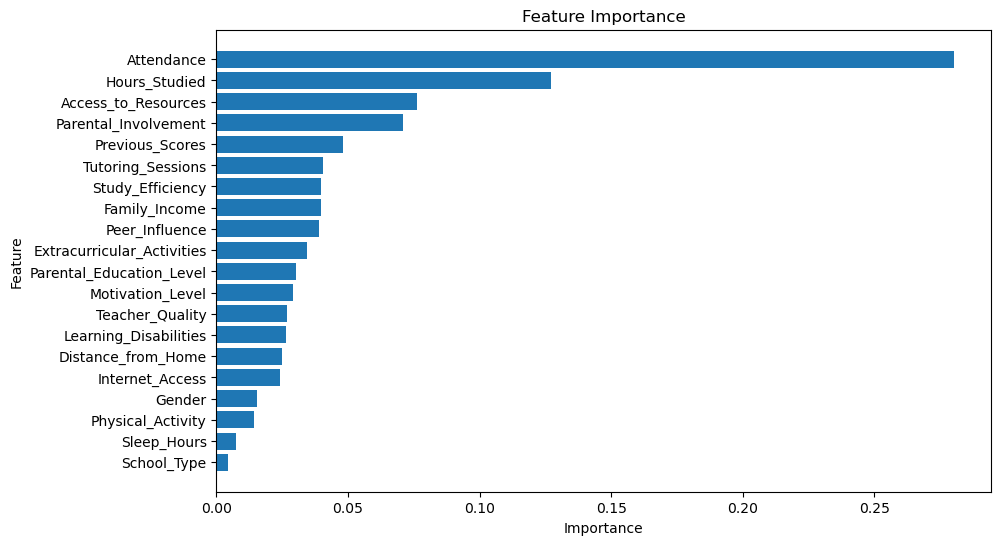

In [41]:
importance = xgb_best.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feat_imp = feat_imp.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    feat_imp["Feature"],
    feat_imp["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.show()

## Feature Importance Interpretation

The feature importance visualization displays which variables contributed most strongly to the predictions generated by the XGBoost component of the ensemble model.

### Observations

- Attendance was identified as the most influential predictor of exam performance.
- Hours studied and access to educational resources also showed strong predictive influence.
- The engineered `Study_Efficiency` feature contributed meaningful predictive value.
- Demographic variables such as gender and school type showed relatively low importance compared to academic and behavioral variables.

### Insights

- Student engagement and study behavior appear more influential than demographic characteristics.
- Consistent attendance strongly contributes to higher predicted exam performance.
- Feature engineering improved the predictive strength of the model by capturing interactions between study habits and productivity.
- The importance rankings increase interpretability by explaining which features most influenced model predictions.

### What This Means for the Model

The feature importance analysis suggests that the ensemble model learned academically meaningful relationships within the dataset. Behavioral and engagement-related variables contributed most heavily to predictions, supporting the validity and interpretability of the model.

## Correlation Heatmap

The correlation heatmap shows pairwise relationships between numerical features. This helps identify which variables are strongly related to exam score and whether any features are highly redundant.

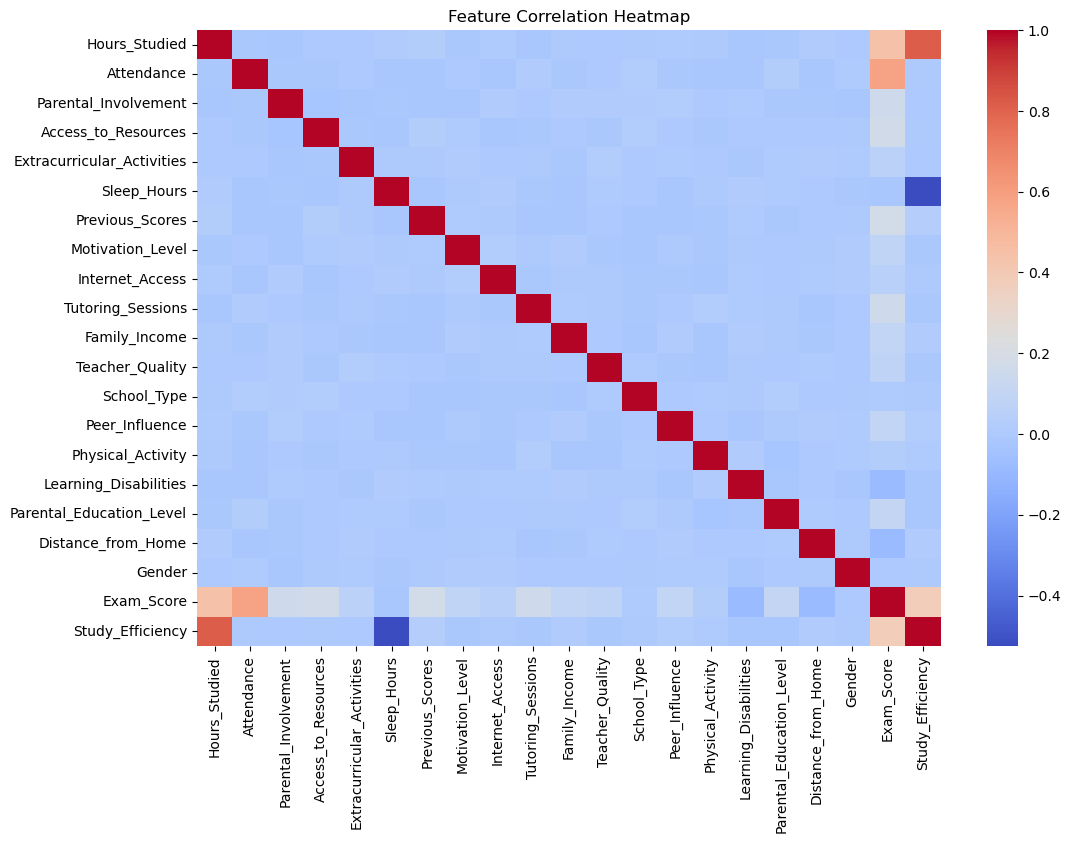

In [44]:
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

## Correlation Heatmap Interpretation

The correlation heatmap visualizes pairwise relationships between numerical variables in the dataset.

### Observations

- Warmer colors represent stronger positive correlations, while cooler colors represent negative correlations.
- Hours studied and study efficiency showed positive relationships with exam scores.
- Sleep hours displayed a slight negative relationship with the engineered study efficiency feature.
- Most variables exhibited relatively low pairwise correlation with one another.

### Insights

- Low multicollinearity among features supports stable model training and reduces redundancy.
- Study-related behaviors appear more predictive of exam performance than demographic variables.
- The engineered `Study_Efficiency` feature successfully captured meaningful relationships within the dataset.
- Correlation patterns reinforce the feature importance findings produced by the ensemble model.

### What This Means for the Model

The heatmap supports the overall validity of the model by showing that important study-related variables maintain meaningful relationships with exam performance. The relatively low multicollinearity among predictors also supports stable and reliable model behavior.

# Final Modeling and Evaluation Summary

This project developed a machine learning regression model to predict student exam scores using behavioral, academic, and demographic features. Since `Exam_Score` is a continuous numerical variable, the problem was approached as a regression task.

The workflow included:

- Data preprocessing and feature engineering
- Train-test splitting
- Baseline model development
- Hyperparameter tuning using Optuna
- Construction of a stacking ensemble model
- Model evaluation using multiple regression metrics
- Visualization and interpretability analysis

The final model combined:

- Linear Regression
- Random Forest Regression
- Optuna-tuned XGBoost Regression

inside a stacking ensemble architecture. This approach allowed the model to capture both linear and nonlinear relationships within the dataset.

### Final Results

The ensemble model achieved strong predictive performance:

- Low MAE and RMSE values demonstrated small prediction errors.
- A strong R² score indicated that the model explained a large proportion of variance in student exam scores.
- Visualizations confirmed stable prediction behavior and good generalization performance.

Feature importance analysis revealed that attendance, study habits, educational resources, and study efficiency were among the strongest predictors of exam performance. Correlation analysis further supported these findings.

Although the model slightly underpredicted a small number of extremely high-performing students, this limitation is realistic and expected due to the relative rarity of such observations in the dataset.

Overall, the project successfully demonstrated the use of ensemble machine learning methods, hyperparameter tuning, feature engineering, and model interpretability techniques to build a strong predictive model for student performance analysis.